In [12]:
from lifelines import KaplanMeierFitter
from lifelines import AalenJohansenFitter
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from lifelines import CoxPHFitter

In [13]:
#Dataframe Notes: 0 = cancer (relapse?), 1 = lost to follow up, 2 = death, competiting
#DT_SECONDCANCER_DEATH, ENDPT_SECONDCANCER_DEATH,
df = pd.read_csv(r"C:\Users\Charm\Downloads\data_clinical_sample_ttnext_cancer_6-2-26.csv")

C:\Users\Charm\AppData\Local\Temp\ipykernel_6172\80286513.py:3: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\Charm\Downloads\data_clinical_sample_ttnext_cancer_6-2-26.csv")


In [14]:
sorted_df = df.sort_values(by = 'CURRENT_AGE_DEID')
dt = sorted_df['DT_SECONDCANCER_DEATH']
censored_val = sorted_df['ENDPT_SECONDCANCER_DEATH']
curr_age = sorted_df['CURRENT_AGE_DEID']

Lets just look at first biopsies then go from there.

In [15]:
df['SAMPLE_ID'].duplicated().sum()

np.int64(0)

In [16]:
sorted_df['DT_SECONDCANCER_DEATH']>0

11896     True
2874      True
1280      True
9170      True
2305      True
         ...  
4205     False
10505     True
4225      True
4226      True
8404      True
Name: DT_SECONDCANCER_DEATH, Length: 12306, dtype: bool

In [17]:
#If time is negative, set it to 0.
#sorted_df.loc[sorted_df['DT_SECONDCANCER_DEATH']<0, 'DT_SECONDCANCER_DEATH'] = 0
#DT_SECONDCANCER_DEATH is Last Date - Start Date, is start date when the patient was diagnosed cancer free from the primary lung cancer and then we're tracking how long it takes for the patient to die or develop second primary lung cancer or is lost to follow up, or is start date the day the patient was diagnosed with the first cancer? The former makes more sense, so I'm assuming the data is left censored and instead of just setting those dates to 0, I'll remove  them.
sorted_df = sorted_df.loc[(sorted_df['DT_SECONDCANCER_DEATH']>0).values]

In [18]:
curr_age.min()

np.int64(4)

In [19]:
curr_age.max()

np.int64(89)

In [20]:
len(curr_age.values)

12306

In [21]:
#sorted_df = df.sort_values(by = 'CURRENT_AGE_DEID')
#sorted_df

In [22]:
age_buckets = curr_age.values.reshape(6,2051)
age_buckets

array([[ 4,  8, 13, ..., 60, 60, 60],
       [60, 60, 60, ..., 67, 67, 67],
       [67, 67, 67, ..., 71, 71, 71],
       [71, 71, 71, ..., 76, 76, 76],
       [76, 76, 76, ..., 81, 81, 81],
       [81, 81, 81, ..., 89, 89, 89]], shape=(6, 2051))

In [23]:
#If we only want 1 to represent the observed effect
sorted_df['Event_of_interest'] =(sorted_df['ENDPT_SECONDCANCER_DEATH'] == 1).astype(int)
sorted_df['Event_of_interest']

11896    0
2874     0
1280     0
9170     0
2305     0
        ..
10526    0
10505    0
4225     0
4226     0
8404     0
Name: Event_of_interest, Length: 11908, dtype: int64

<Axes: >

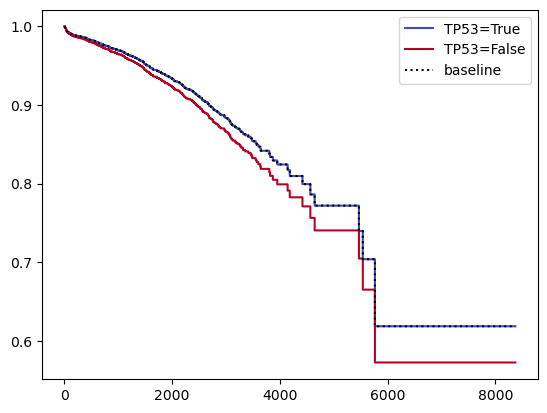

In [37]:
#Filter the df so that I don't get a value error because of the text columns...
cph_df = sorted_df[['DT_SECONDCANCER_DEATH', 'Event_of_interest', 'TP53', 'CURRENT_AGE_DEID', 'KRAS']]
cph = CoxPHFitter()
cph.fit(cph_df, duration_col = 'DT_SECONDCANCER_DEATH', event_col = 'Event_of_interest')
cph.plot_partial_effects_on_outcome(covariates='TP53', values=[True, False], cmap='coolwarm')

In [25]:
#[i for i in sorted_df['CURRENT_AGE_DEID'].values]

In [26]:
#cph.fit(cph_df, duration_col = 'DT_SECONDCANCER_DEATH', event_col = 'Event_of_interest')
#cph.plot_partial_effects_on_outcome(covariates='CURRENT_AGE_DEID', values=[i for i in sorted_df['CURRENT_AGE_DEID'].values], cmap='coolwarm')


In [27]:
print(sorted_df['Event_of_interest'].dtypes, sorted_df['DT_SECONDCANCER_DEATH'].dtypes)

int64 int64


Let's make a cumulative incidence function, since lifelines doesn't have fine gray, we can use Aalen Johansen but it doesn't account for covariants (whereas the Cox Proportional Hazard Function accounts for covariants but not for competing factors...)

             CIF_1
event_at          
0.0       0.000000
1.0       0.000084
2.0       0.000168
3.0       0.000168
5.0       0.000168
...            ...
7355.0    0.460797
7498.0    0.460797
7853.0    0.460797
8305.0    0.460797
8372.0    0.460797

[3143 rows x 1 columns]


<Axes: xlabel='event_at'>

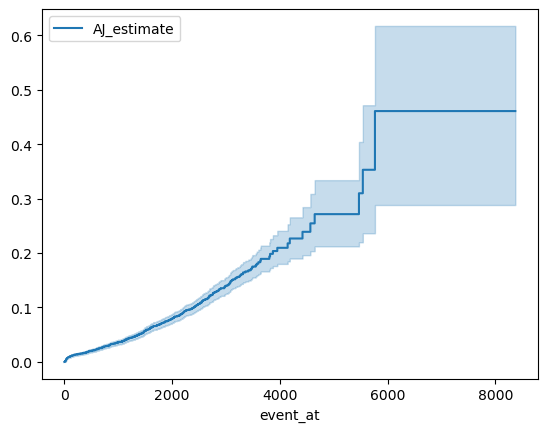

In [34]:
ajf = AalenJohansenFitter(calculate_variance = True)
ajf.fit(cph_df['DT_SECONDCANCER_DEATH'], cph_df['Event_of_interest'], event_of_interest=1)
print(ajf.cumulative_density_)
ajf.plot()

So the rate for someone who has experienced a first primary cancer experiencing a second primary cancer is 46% ?

Let's stratifying between people with TP53 mutation and those without.

In [29]:
mutated_TP53 = cph_df[cph_df['TP53'] == True]
nonmutated_TP53 = cph_df[cph_df['TP53'] == False]

<Axes: xlabel='event_at'>

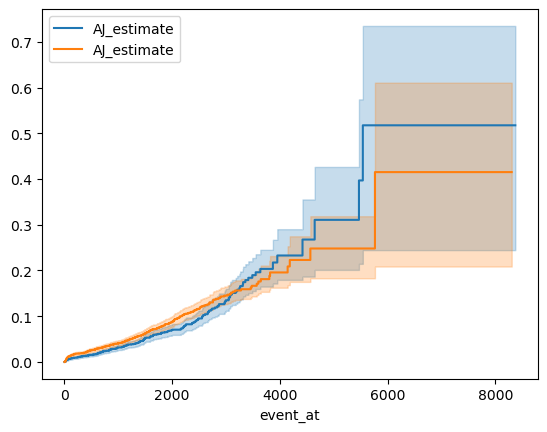

In [30]:
ajf.fit(mutated_TP53['DT_SECONDCANCER_DEATH'], mutated_TP53['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()
ajf.fit(nonmutated_TP53['DT_SECONDCANCER_DEATH'], nonmutated_TP53['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()
#Blue is mutated, Orange is unmutated

If the individual developed a secondary cancer, lets see how high the incidence is for someone with a TP53 and KRAS mutation

<Axes: xlabel='event_at'>

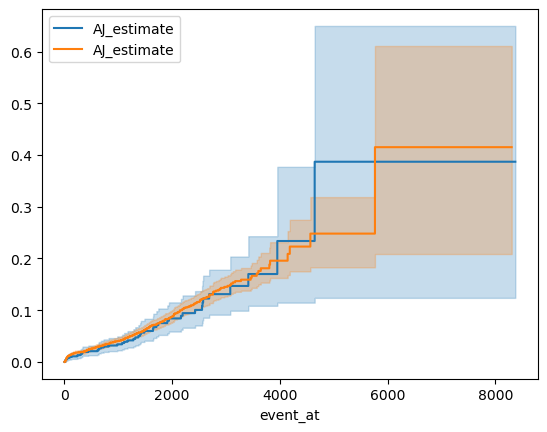

In [31]:
mutated_TP53_KRAS = mutated_TP53[mutated_TP53['KRAS'] == True]
ajf.fit(mutated_TP53_KRAS['DT_SECONDCANCER_DEATH'], mutated_TP53_KRAS['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()
ajf.fit(nonmutated_TP53['DT_SECONDCANCER_DEATH'], nonmutated_TP53['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()

Lets look at how age impacts CIF


<Axes: xlabel='event_at'>

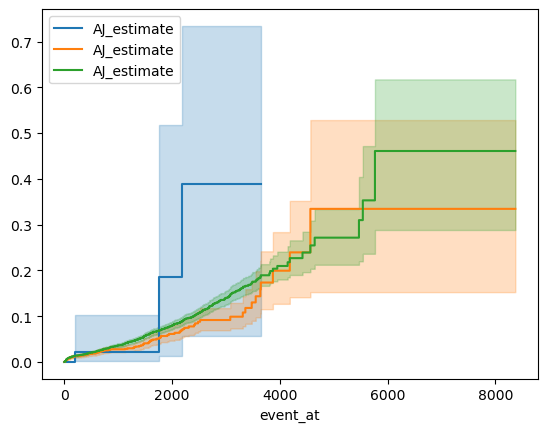

In [32]:
group_1 = cph_df[cph_df['CURRENT_AGE_DEID'] <= 32]
group_2 = cph_df[cph_df['CURRENT_AGE_DEID'] <= 65]
group_3 = cph_df[cph_df['CURRENT_AGE_DEID'] <= 99]
ajf.fit(group_1['DT_SECONDCANCER_DEATH'], group_1['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()
ajf.fit(group_2['DT_SECONDCANCER_DEATH'], group_2['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()
ajf.fit(group_3['DT_SECONDCANCER_DEATH'], group_3['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()
#Blue, orange, green

Let's compare incidence based on stage of cancer.

In [41]:
sorted_df['STAGE_HIGHEST_RECORDED'].unique()

array(['Unknown', 'Stage 1-3', 'Stage 4'], dtype=object)

<Axes: xlabel='event_at'>

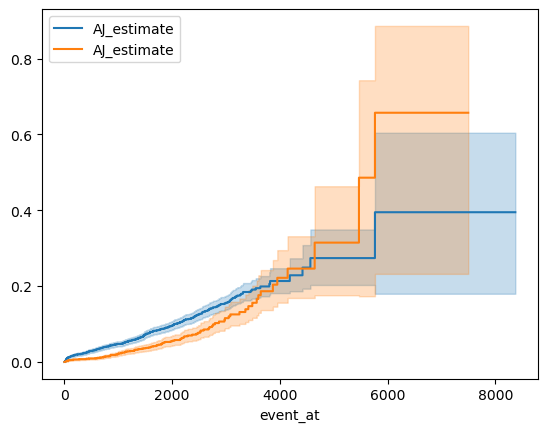

In [45]:
sorted_df_S13 = sorted_df[sorted_df['STAGE_HIGHEST_RECORDED'] == 'Stage 1-3']
group_1 = sorted_df_S13[['DT_SECONDCANCER_DEATH', 'Event_of_interest', 'TP53', 'CURRENT_AGE_DEID', 'KRAS']]
sorted_df_S4 = sorted_df[sorted_df['STAGE_HIGHEST_RECORDED'] == 'Stage 4']
group_2 = sorted_df_S4[['DT_SECONDCANCER_DEATH', 'Event_of_interest', 'TP53', 'CURRENT_AGE_DEID', 'KRAS']]
ajf.fit(group_1['DT_SECONDCANCER_DEATH'], group_1['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()
ajf.fit(group_2['DT_SECONDCANCER_DEATH'], group_2['Event_of_interest'], event_of_interest=1)
ajf.cumulative_density_
ajf.plot()

People diagnosed with Stage 4 primary lung cancer are at a higher risk of a second primary lung cancer than those diagnosed with Stages 1-3 after 10 years...?